# Custom physics

Add your own laws without touching jbubble. Subclass `Property` for a state-dependent coefficient, subclass `MediumModel` for a new surrounding medium, and plug both into `KellerMiksis`. Then replace a law that you don't know with a neural network through `NeuralProperty`, and differentiate a simulation with respect to its weights.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jbubble import run_simulation
from jbubble.bubble.eom import KellerMiksis
from jbubble.bubble.gas import PolytropicGas
from jbubble.bubble.medium import MediumModel, NeoHookeanMedium
from jbubble.bubble.property import NeuralProperty, Property
from jbubble.bubble.shell import LipidShell
from jbubble.bubble.state import BubbleState
from jbubble.pulse import ToneBurst
from jbubble.pulse.shapes import Sine
from jbubble.utils.presets import lipid_bubble

plt.style.use("jbubble.style.light")
DRIVE_COLOUR = "#8c959f"  # the light theme's neutral grey for the drive

## A custom `Property`: a shear-thinning shell viscosity

A `Property` is an Equinox module that maps a `BubbleState` to a scalar. Every model field that takes a property, such as a shell's surface tension `sigma` or its dilatational viscosity `kappa_s`, accepts your subclass. Its fields are ordinary pytree leaves, so `jax.grad` reaches them.

Doinikov, Haac, and Dayton (2009) found that a lipid shell's viscosity falls as the shell deforms faster. Their shear-thinning law depends on the wall strain rate $\dot{R}/R$, so it reads both `state.R` and `state.R_dot`. The parameter values here are illustrative.

In [2]:
class ShearThinningViscosity(Property):
    r"""Shell dilatational viscosity that falls with the wall strain rate.

    ::

        kappa_s = kappa_0 / (1 + alpha * |R_dot / R|)

    Parameters
    ----------
    kappa_0 : float
        Viscosity at rest [kg/s].
    alpha : float
        Thinning time constant [s].
    """

    kappa_0: float
    alpha: float

    def __call__(self, state: BubbleState) -> jax.Array:
        strain_rate = state.R_dot / state.R
        return self.kappa_0 / (1.0 + self.alpha * jnp.abs(strain_rate))


thinning = ShearThinningViscosity(kappa_0=7.5e-9, alpha=2e-6)
preset_shell = lipid_bubble().eom.shell  # SmoothMarmottant sigma, constant kappa_s


def evaluate(law, R_ratio=1.0, strain_rate=0.0, R0=1e-6):
    """Evaluate a `state -> scalar` law at radii `R_ratio * R0` and rates `R_dot / R`."""
    R_ratio, strain_rate = jnp.broadcast_arrays(
        jnp.asarray(R_ratio, float), jnp.asarray(strain_rate, float)
    )

    def one(x, rate):
        return law(BubbleState(R=x * R0, R_dot=rate * x * R0, R0=jnp.asarray(R0)))

    return jax.vmap(one)(R_ratio, strain_rate)

## A custom `MediumModel`: Mooney-Rivlin tissue

A medium returns the stress that the surroundings exert on the bubble wall, split into a viscous and an elastic part. The built-in `NeoHookeanMedium` saturates at $5G/2$ when the bubble grows. A Mooney-Rivlin solid adds a term from the second strain invariant that keeps stiffening, as in the nonlinear tissue models of Gaudron, Warnez, and Johnsen (2015). With $C_1 = (1-\alpha)G/2$ and $C_2 = \alpha G/2$, integrating its stress through the incompressible solid gives

$$
p_\text{elastic} = (1-\alpha)\,\frac{G}{2}\left[5 - 4\frac{R_0}{R}
    - \left(\frac{R_0}{R}\right)^4\right]
    + \alpha G\left[2\frac{R}{R_0} - 1 - \left(\frac{R_0}{R}\right)^2\right].
$$

`alpha = 0` is the neo-Hookean solid, and every `alpha` has the same small-strain modulus $G$.

In [3]:
class MooneyRivlinMedium(MediumModel):
    r"""Mooney-Rivlin viscoelastic solid around the bubble.

    ::

        p_medium = 4 mu R_dot / R
            + (1 - alpha) (G / 2) [5 - 4 (R0/R) - (R0/R)**4]
            + alpha G [2 (R/R0) - 1 - (R0/R)**2]

    Parameters
    ----------
    mu : float or Property
        Dynamic viscosity [Pa s], inherited from `MediumModel`.
    G : float
        Small-strain shear modulus [Pa].
    alpha : float
        Weight of the second-invariant term, from 0 (neo-Hookean) to 1.
    rho_L, c_L : float
        Density [kg/m³] and speed of sound [m/s] of the surrounding
        liquid, inherited from `MediumModel` as keyword-only fields.
    """

    G: float
    alpha: float

    def p_viscous(self, state: BubbleState) -> jax.Array:
        return 4.0 * self.mu(state) * state.R_dot / state.R

    def p_elastic(self, state: BubbleState) -> jax.Array:
        x = state.R0 / state.R
        neo_hookean = 0.5 * (5.0 - 4.0 * x - x**4)
        second_invariant = 2.0 / x - 1.0 - x**2
        return self.G * (
            (1.0 - self.alpha) * neo_hookean + self.alpha * second_invariant
        )

Check the new class before you trust it. With `alpha = 0` it must reproduce the built-in `NeoHookeanMedium`, and for any `alpha` it must match a numerical quadrature of the stress integral $2\int_1^{R/R_0} 2(C_1 + C_2\lambda^2)(\lambda^3 + 1)\lambda^{-5}\, \mathrm{d}\lambda$.

In [4]:
G_TISSUE, MU_TISSUE = 100e3, 0.015  # shear modulus [Pa] and viscosity [Pa s]
TISSUE = {"rho_L": 1060.0, "c_L": 1540.0}  # density [kg/m³] and sound speed [m/s]
stretch = jnp.linspace(0.5, 4.0, 200)  # R / R0

custom = MooneyRivlinMedium(mu=MU_TISSUE, G=G_TISSUE, alpha=0.0)
built_in = NeoHookeanMedium(mu=MU_TISSUE, G=G_TISSUE, **TISSUE)
gap = jnp.max(
    jnp.abs(evaluate(custom.p_elastic, stretch) - evaluate(built_in.p_elastic, stretch))
)
print(f"alpha = 0 against NeoHookeanMedium: max difference {float(gap):.1e} Pa")


def quadrature(stretch_ratio, alpha, n=20_001):
    c1, c2 = (1 - alpha) * G_TISSUE / 2, alpha * G_TISSUE / 2
    lam = jnp.linspace(1.0, stretch_ratio, n)
    integrand = 2 * (c1 + c2 * lam**2) * (lam**3 + 1) / lam**5
    return 2 * jnp.trapezoid(integrand, lam)


for alpha in (0.5, 1.0):
    medium = MooneyRivlinMedium(mu=MU_TISSUE, G=G_TISSUE, alpha=alpha)
    closed = evaluate(medium.p_elastic, stretch)
    numeric = jax.vmap(lambda s, a=alpha: quadrature(s, a))(stretch)
    error = jnp.max(jnp.abs(closed - numeric) / jnp.abs(numeric).clip(1.0))
    print(f"alpha = {alpha} against quadrature: max relative error {float(error):.1e}")

alpha = 0 against NeoHookeanMedium: max difference 0.0e+00 Pa


alpha = 0.5 against quadrature: max relative error 4.2e-09
alpha = 1.0 against quadrature: max relative error 1.6e-09


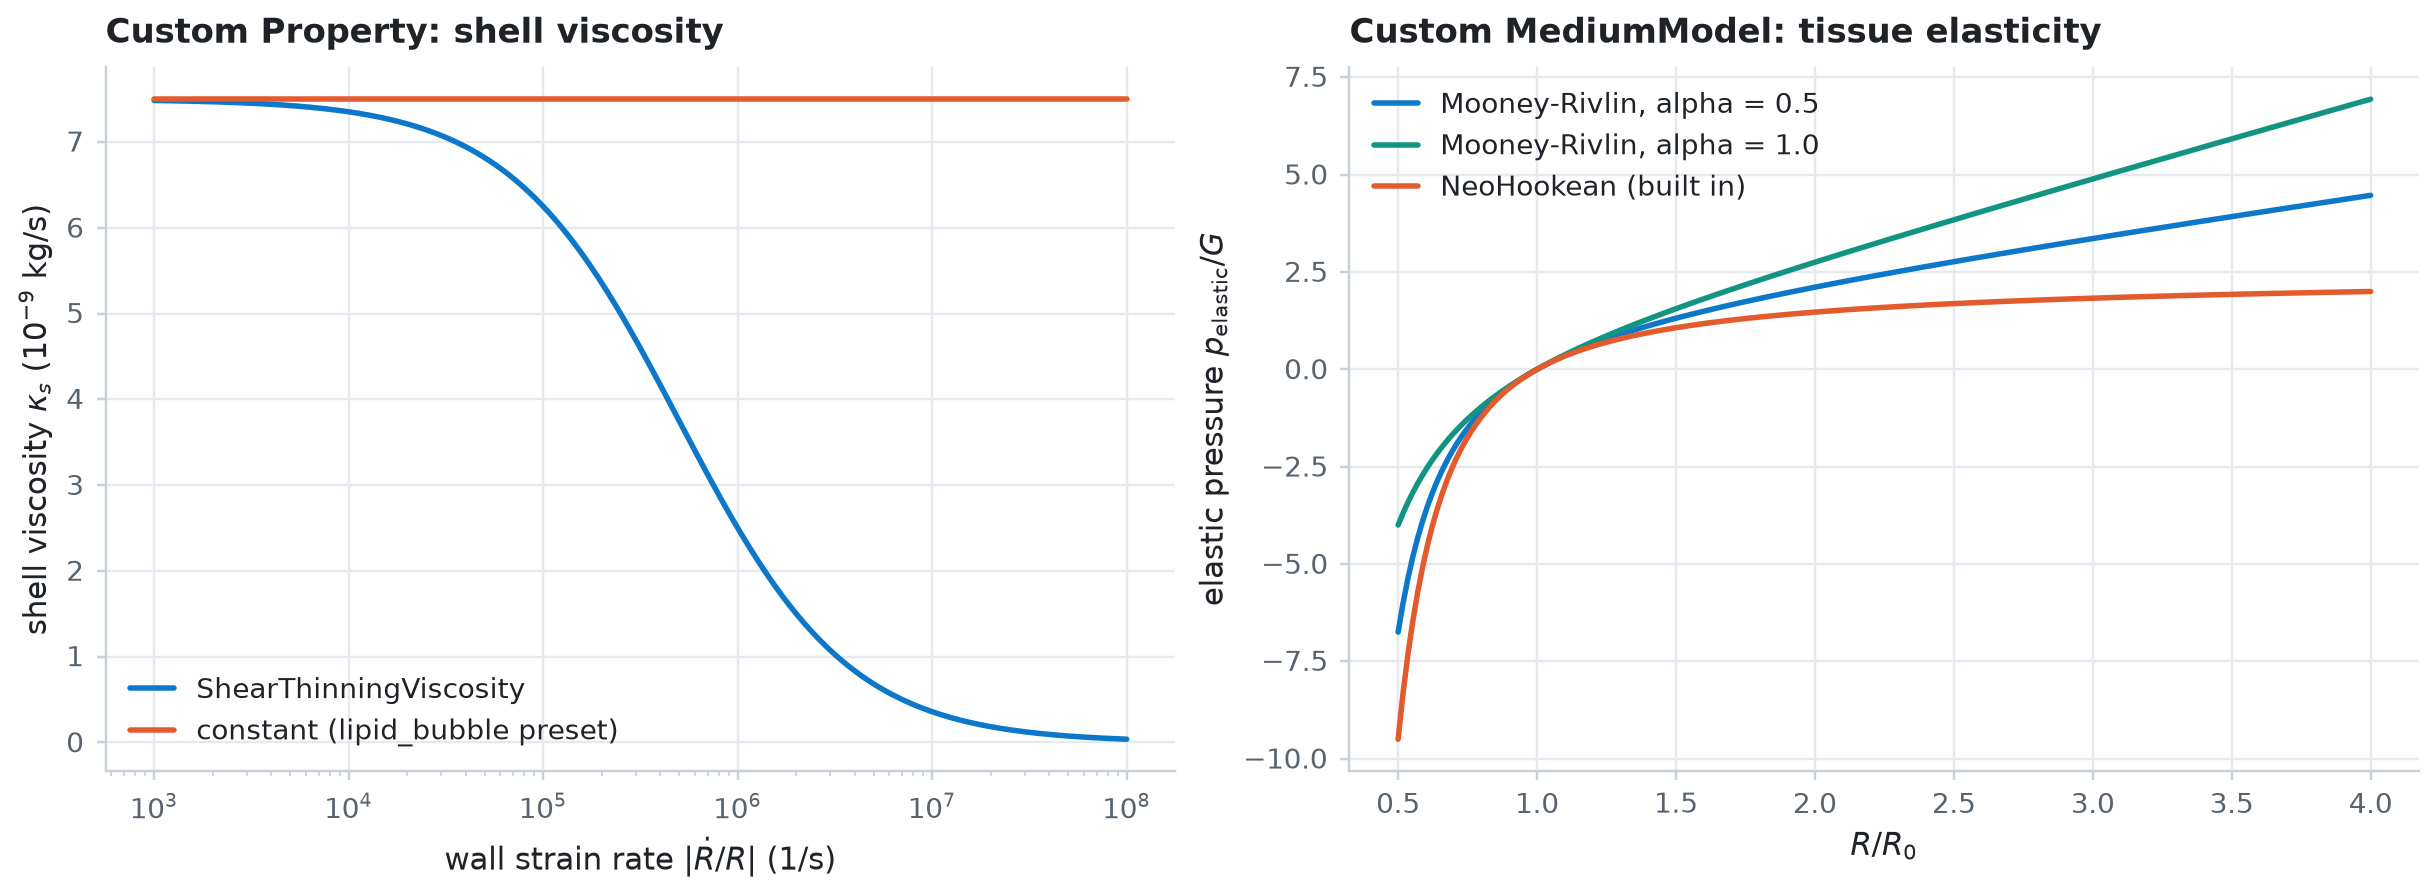

In [5]:
rates = jnp.logspace(3, 8, 200)  # |R_dot / R| [1/s]
fig, (ax_k, ax_m) = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
ax_k.plot(
    rates,
    evaluate(thinning, strain_rate=rates) * 1e9,
    color="C0",
    label="ShearThinningViscosity",
)
ax_k.plot(
    rates,
    evaluate(preset_shell.kappa_s, strain_rate=rates) * 1e9,
    color="C1",
    label="constant (lipid_bubble preset)",
)
ax_k.set_xscale("log")
ax_k.set_xlabel("wall strain rate $|\\dot{R}/R|$ (1/s)")
ax_k.set_ylabel("shell viscosity $\\kappa_s$ (10$^{-9}$ kg/s)")
ax_k.set_title("Custom Property: shell viscosity")
ax_k.legend(loc="lower left")

for colour, alpha in [("C0", 0.5), ("C2", 1.0)]:
    medium = MooneyRivlinMedium(mu=MU_TISSUE, G=G_TISSUE, alpha=alpha)
    ax_m.plot(
        stretch,
        evaluate(medium.p_elastic, stretch) / G_TISSUE,
        color=colour,
        label=f"Mooney-Rivlin, alpha = {alpha}",
    )
ax_m.plot(
    stretch,
    evaluate(built_in.p_elastic, stretch) / G_TISSUE,
    color="C1",
    label="NeoHookean (built in)",
)
ax_m.set_xlabel("$R/R_0$")
ax_m.set_ylabel("elastic pressure $p_\\text{elastic}/G$")
ax_m.set_title("Custom MediumModel: tissue elasticity")
ax_m.legend(loc="upper left")
plt.show()

## Plug them into an equation of motion

An equation of motion takes any gas, shell, and medium. Build a 2 µm lipid-shelled bubble with the shear-thinning shell, put it in tissue, and drive it hard enough to stretch the tissue several times. The Mooney-Rivlin tissue stiffens as the bubble grows, so the bubble expands less than in neo-Hookean tissue with the same small-strain modulus.

In [6]:
def tissue_bubble(medium, kappa_s=thinning):
    return KellerMiksis(
        gas=PolytropicGas(gamma=1.095),
        shell=LipidShell(sigma=preset_shell.sigma, kappa_s=kappa_s),
        medium=medium,
        R0=2e-6,
        P_amb=101325.0,
    )


pulse = ToneBurst(freq=1e6, pressure=1e6, shape=Sine(), cycle_num=5)
media = {
    "NeoHookean (built in)": ("C1", built_in),
    "Mooney-Rivlin, alpha = 0.5": (
        "C0",
        MooneyRivlinMedium(mu=MU_TISSUE, G=G_TISSUE, alpha=0.5, **TISSUE),
    ),
    "Mooney-Rivlin, alpha = 1": (
        "C2",
        MooneyRivlinMedium(mu=MU_TISSUE, G=G_TISSUE, alpha=1.0, **TISSUE),
    ),
}
results = {
    name: run_simulation(tissue_bubble(m), pulse) for name, (_, m) in media.items()
}
for name, res in results.items():
    print(f"{name:27s} R_max/R0 = {float(res.radius.max() / 2e-6):.2f}")
mooney_rivlin = media["Mooney-Rivlin, alpha = 0.5"][1]
constant = run_simulation(tissue_bubble(mooney_rivlin, kappa_s=7.5e-9), pulse)
print(
    "Mooney-Rivlin, alpha = 0.5, with a constant kappa_s: "
    f"R_max/R0 = {float(constant.radius.max() / 2e-6):.2f}"
)

NeoHookean (built in)       R_max/R0 = 4.19
Mooney-Rivlin, alpha = 0.5  R_max/R0 = 3.76
Mooney-Rivlin, alpha = 1    R_max/R0 = 3.44


Mooney-Rivlin, alpha = 0.5, with a constant kappa_s: R_max/R0 = 3.65


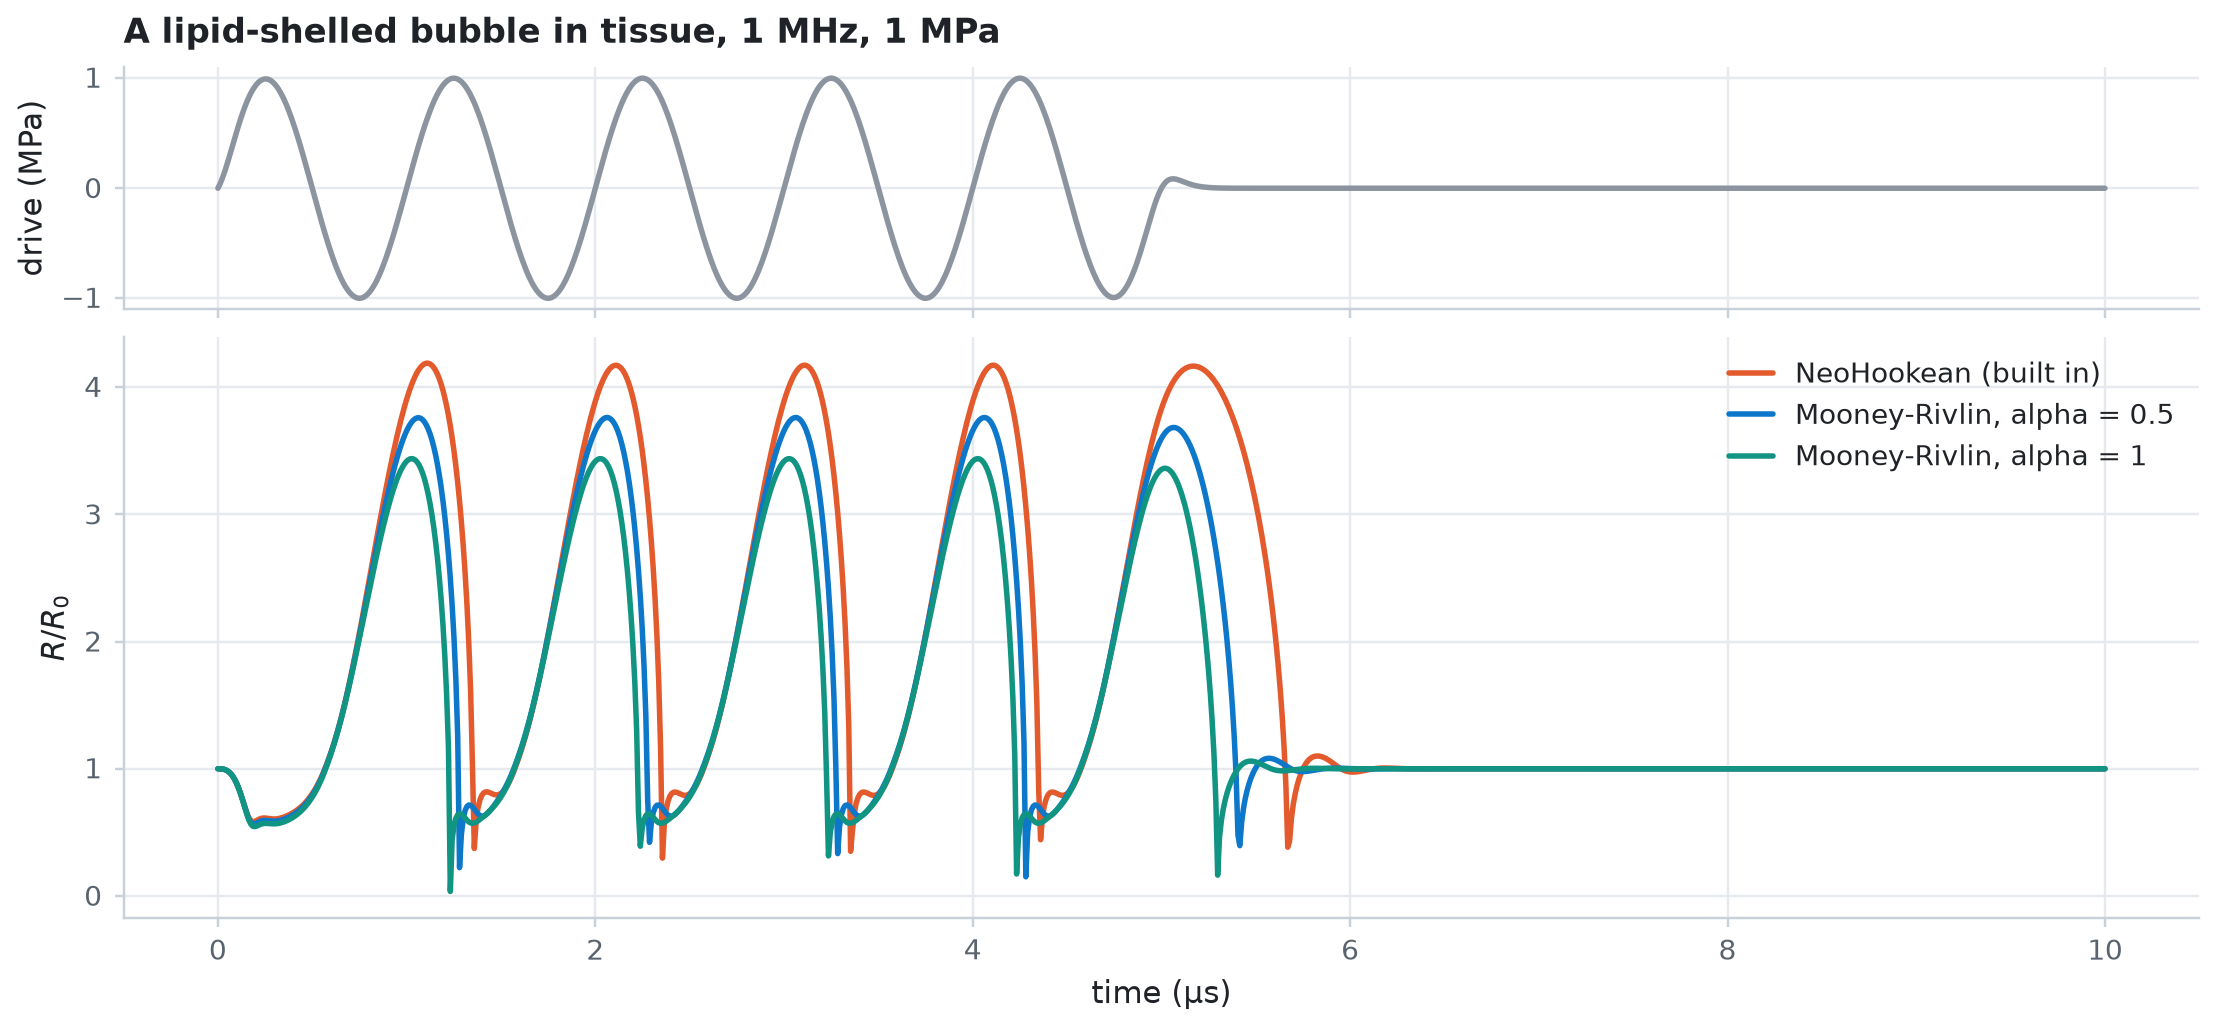

In [7]:
fig, (ax_drive, ax_r) = plt.subplots(
    2, 1, figsize=(10, 4.6), sharex=True, height_ratios=[1, 2.4], layout="constrained"
)
first = next(iter(results.values()))
t_us = np.asarray(first.ts) * 1e6
ax_drive.plot(t_us, np.asarray(first.driving_pressure) / 1e6, color=DRIVE_COLOUR)
ax_drive.set_ylabel("drive (MPa)")
ax_drive.set_title("A lipid-shelled bubble in tissue, 1 MHz, 1 MPa")
for name, res in results.items():
    ax_r.plot(t_us, np.asarray(res.radius) / 2e-6, color=media[name][0], label=name)
ax_r.set_xlabel("time (µs)")
ax_r.set_ylabel("$R/R_0$")
ax_r.legend(loc="upper right")
plt.show()

## Learn a law you don't know: `NeuralProperty`

When the law itself is the unknown, put a neural network in its place. `NeuralProperty` feeds $R/R_0$ to an Equinox network and returns its single output. Choose the `final_activation` to keep the output physical: here a scaled sigmoid bounds the surface tension between 0, a buckled shell, and 72 mN/m, bare water.

`eqx.tree_at` swaps the network into the `lipid_bubble` preset in place of its surface tension law. The untrained network gives a wrong radius curve, and `eqx.filter_value_and_grad` differentiates the mismatch with respect to every weight, through the ODE solve.

In [8]:
SIGMA_MAX = 0.072  # surface tension of water [N/m]
mlp = eqx.nn.MLP(
    in_size=1,
    out_size=1,
    width_size=16,
    depth=2,
    activation=jax.nn.tanh,
    final_activation=lambda x: SIGMA_MAX * jax.nn.sigmoid(x),
    key=jax.random.key(0),
)
sigma_net = NeuralProperty(net=mlp)

preset = lipid_bubble()
target = run_simulation(preset.eom, preset.pulse).radius / preset.eom.R0


def mismatch(sigma):
    eom = eqx.tree_at(lambda e: e.shell.sigma, preset.eom, sigma)
    radius = run_simulation(eom, preset.pulse).radius / preset.eom.R0
    return jnp.mean((radius - target) ** 2)


loss, grads = eqx.filter_jit(eqx.filter_value_and_grad(mismatch))(sigma_net)
weights = jax.tree.leaves(eqx.filter(sigma_net, eqx.is_array))
grad_leaves = jax.tree.leaves(eqx.filter(grads, eqx.is_array))
norm = jnp.sqrt(sum(jnp.sum(g**2) for g in grad_leaves))
print(f"Network parameters: {sum(w.size for w in weights)}")
print(f"Mismatch with the Marmottant bubble: {float(loss):.2e}")
print(
    f"Gradient norm: {float(norm):.2e}, all finite: "
    f"{all(bool(jnp.all(jnp.isfinite(g))) for g in grad_leaves)}"
)

Network parameters: 321
Mismatch with the Marmottant bubble: 2.46e-02


Gradient norm: 2.21e-02, all finite: True


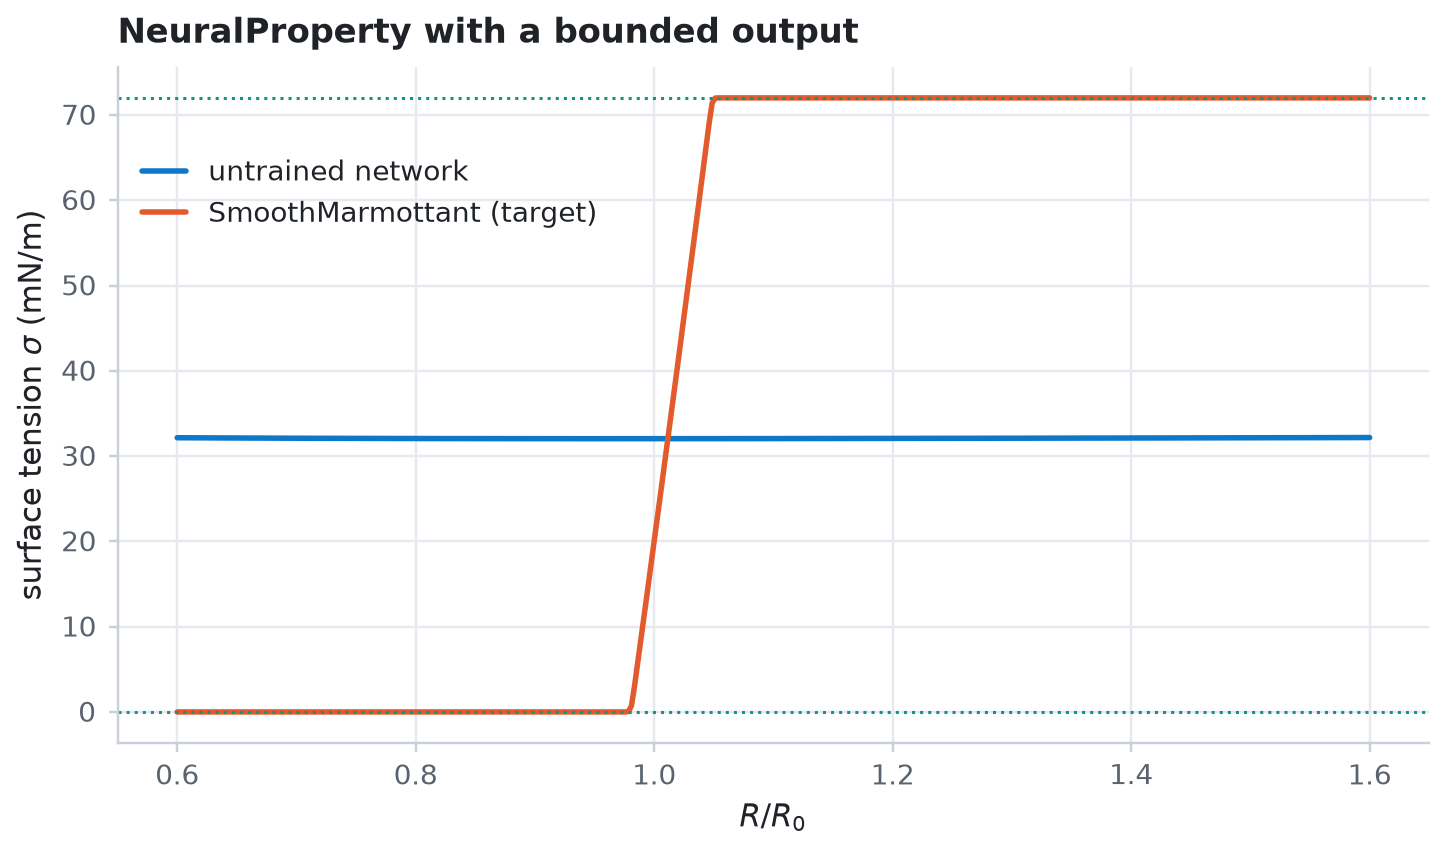

In [9]:
ratio = jnp.linspace(0.6, 1.6, 400)  # R / R0
fig, ax = plt.subplots(figsize=(6.5, 3.8), layout="constrained")
ax.plot(ratio, evaluate(sigma_net, ratio) * 1e3, color="C0", label="untrained network")
ax.plot(
    ratio,
    evaluate(preset_shell.sigma, ratio) * 1e3,
    color="C1",
    label="SmoothMarmottant (target)",
)
for bound in (0.0, SIGMA_MAX * 1e3):
    ax.axhline(bound, color="C2", ls=":", lw=1)
ax.set_xlabel("$R/R_0$")
ax.set_ylabel("surface tension $\\sigma$ (mN/m)")
ax.set_title("NeuralProperty with a bounded output")
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.9))
plt.show()

Example 11 trains a network like this one with `fit_parameters` to recover the Marmottant law from radius curves alone.

## References

- Doinikov, A. A., Haac, J. F., & Dayton, P. A. (2009). Modeling of nonlinear viscous stress in encapsulating shells of lipid-coated contrast agent microbubbles. *Ultrasonics*, 49(2), 269-275.
- Gaudron, R., Warnez, M. T., & Johnsen, E. (2015). Bubble dynamics in a viscoelastic medium with nonlinear elasticity. *Journal of Fluid Mechanics*, 766, 54-75.